In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import TripletNet, identity_loss

Using TensorFlow backend.
/opt/conda/envs/project/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:523: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
/opt/conda/envs/project/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:524: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
/opt/conda/envs/project/lib/python3.6/site-packages/tensorflow/python/framework/dtypes.py:525: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1)])
/opt/conda/envs/project/lib/python3.6/site-packages/t

In [2]:
file_path = '/workspaces/work/Dataset/dataset/Test/Train/dataset_training_aug.h5',
          # './dataset/Train/dataset_training_aug.h5'  
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0,1000, dtype = int), 
snr_range = np.arange(20,80)



In [5]:
def train_feature_extractor(
        file_path = 
        '/workspaces/work/Dataset/dataset/Test/Train/dataset_training_aug.h5'
          # './dataset/Train/dataset_training_aug.h5'  
         , 
        dev_range = np.arange(0,30, dtype = int), 
        pkt_range = np.arange(0,1000, dtype = int), 
        snr_range = np.arange(20,80)
                            ):
    '''
    train_feature_extractor trains an RFF extractor using triplet loss.
    
    INPUT: 
        FILE_PATH is the path of training dataset.
        
        DEV_RANGE is the label range of LoRa devices to train the RFF extractor.
        
        PKT_RANGE is the range of packets from each LoRa device to train the RFF extractor.
        
        SNR_RANGE is the SNR range used in data augmentation. 
        
    RETURN:
        FEATURE_EXTRACTOR is the RFF extractor which can extract features from
        channel-independent spectrograms.
    '''
    
    LoadDatasetObj = LoadDataset()
    
    # Load preamble IQ samples and labels.
    data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)
    
    # Add additive Gaussian noise to the IQ samples.
    data = awgn(data, snr_range)
    
    ChannelIndSpectrogramObj = ChannelIndSpectrogram()
    
    # Convert time-domain IQ samples to channel-independent spectrograms.
    data = ChannelIndSpectrogramObj.channel_ind_spectrogram(data)
    
    # Specify hyper-parameters during training.
    margin = 0.1
    batch_size = 32
    patience = 20
    
    TripletNetObj = TripletNet()
    
    # Create an RFF extractor.
    feature_extractor = TripletNetObj.feature_extractor(data.shape)
    
    # Create the Triplet net using the RFF extractor.
    triplet_net = TripletNetObj.create_triplet_net(feature_extractor, margin)

    # Create callbacks during training. The training stops when validation loss 
    # does not decrease for 30 epochs.
    early_stop = EarlyStopping('val_loss', 
                               min_delta = 0, 
                               patience = 
                               patience)
    
    reduce_lr = ReduceLROnPlateau('val_loss', 
                                  min_delta = 0, 
                                  factor = 0.2, 
                                  patience = 10, 
                                  verbose=1)
    callbacks = [early_stop, reduce_lr]
    
    # Split the dasetset into validation and training sets.
    data_train, data_valid, label_train, label_valid = train_test_split(data, 
                                                                        label, 
                                                                        test_size=0.1, 
                                                                        shuffle= True)
    del data, label
    
    # Create the trainining generator.
    train_generator = TripletNetObj.create_generator(batch_size, 
                                                     dev_range, 
                                                     data_train, 
                                                     label_train)
    # Create the validation generator.
    valid_generator = TripletNetObj.create_generator(batch_size, 
                                                     dev_range, 
                                                     data_valid, 
                                                     label_valid)
    
    
    # Use the RMSprop optimizer for training.
    opt = RMSprop(learning_rate=1e-3)
    triplet_net.compile(loss = identity_loss, optimizer = opt)

    # Start training.
    history = triplet_net.fit(train_generator,
                              steps_per_epoch = data_train.shape[0]//batch_size,
                              epochs = 1000,
                              validation_data = valid_generator,
                              validation_steps = data_valid.shape[0]//batch_size,
                              verbose=1, 
                              callbacks = callbacks)
    
    return feature_extractor

In [6]:
def test_classification(
        file_path_enrol,
        file_path_clf,
        feature_extractor_name,
        dev_range_enrol = np.arange(30,40, dtype = int),
        pkt_range_enrol = np.arange(0,100, dtype = int),
        dev_range_clf = np.arange(30,40, dtype = int),
        pkt_range_clf = np.arange(100,200, dtype = int)
                        ):
    '''
    test_classification performs a classification task and returns the 
    classification accuracy.
    
    INPUT: 
        FILE_PATH_ENROL is the path of enrollment dataset.
        
        FILE_PATH_CLF is the path of classification dataset.
        
        FEATURE_EXTRACTOR_NAME is the name of RFF extractor used during 
        enrollment and classification. 
        
        DEV_RANGE_ENROL is the label range of LoRa devices during enrollment.
        
        PKT_RANGE_ENROL is the range of packets from each LoRa device during enrollment.
        
        DEV_RANGE_CLF is the label range of LoRa devices during classification.
        
        PKT_RANGE_CLF is the range of packets from each LoRa device during classification.

    RETURN:
        PRED_LABEL is the list of predicted labels.
        
        TRUE_LABEL is the list true labels.
        
        ACC is the overall classification accuracy.
    '''
    
    # Load the saved RFF extractor.
    feature_extractor = load_model(feature_extractor_name, compile=False)
    
    LoadDatasetObj = LoadDataset()
    
    # Load the enrollment dataset. (IQ samples and labels)
    data_enrol, label_enrol = LoadDatasetObj.load_iq_samples(file_path_enrol, 
                                                             dev_range_enrol, 
                                                             pkt_range_enrol)
    
    ChannelIndSpectrogramObj = ChannelIndSpectrogram()
    
    # Convert IQ samples to channel independent spectrograms. (enrollment data)
    data_enrol = ChannelIndSpectrogramObj.channel_ind_spectrogram(data_enrol)
    
    # # Visualize channel independent spectrogram
    # plt.figure()
    # sns.heatmap(data_enrol[0,:,:,0],xticklabels=[], yticklabels=[], cmap='Blues', cbar=False)
    # plt.gca().invert_yaxis()
    # plt.savefig('channel_ind_spectrogram.pdf')
    
    # Extract RFFs from channel independent spectrograms.
    feature_enrol = feature_extractor.predict(data_enrol)
    del data_enrol
    
    # Create a K-NN classifier using the RFFs extracted from the enrollment dataset.
    knnclf=KNeighborsClassifier(n_neighbors=15,metric='euclidean')
    knnclf.fit(feature_enrol, np.ravel(label_enrol))
    
    
    # Load the classification dataset. (IQ samples and labels)
    data_clf, true_label = LoadDatasetObj.load_iq_samples(file_path_clf, 
                                                         dev_range_clf, 
                                                         pkt_range_clf)
    
    # Convert IQ samples to channel independent spectrograms. (classification data)
    data_clf = ChannelIndSpectrogramObj.channel_ind_spectrogram(data_clf)

    # Extract RFFs from channel independent spectrograms.
    feature_clf = feature_extractor.predict(data_clf)
    del data_clf
    
    # Make prediction using the K-NN classifier.
    pred_label = knnclf.predict(feature_clf)

    # Calculate classification accuracy.
    acc = accuracy_score(true_label, pred_label)
    print('Overall accuracy = %.4f' % acc)
    
    return pred_label, true_label, acc

In [7]:
def test_rogue_device_detection(
    feature_extractor_name,
    file_path_enrol= '/workspaces/work/Dataset/dataset/Test/dataset_residential.h5',
        #'./dataset/Test/dataset_residential.h5',
    dev_range_enrol = np.arange(30,40, dtype = int),
    pkt_range_enrol = np.arange(0,100, dtype = int),
    file_path_legitimate = '/workspaces/work/Dataset/dataset/Test/dataset_residential.h5',
        #'./dataset/Test/dataset_residential.h5',
    dev_range_legitimate = np.arange(30,40, dtype = int),
    pkt_range_legitimate = np.arange(100,200, dtype = int),
    file_path_rogue ='/workspaces/work/Dataset/dataset/Test/dataset_rogue.h5',
     # './dataset/Test/dataset_rogue.h5',
    dev_range_rogue = np.arange(40,45, dtype = int),
    pkt_range_rogue = np.arange(0,100, dtype = int),
    ):

    '''
    test_rogue_device_detection performs the rogue device detection task using
    a specific RFF extractor. It returns false positive rate (FPR), true 
    positive rate (TPR), area under the curve (AUC) and corresponding threshold 
    settings.
    
    INPUT: 
    
        FEATURE_EXTRACTOR_NAME is the name of RFF extractor used in rogue 
        device detection.
        
        FILE_PATH_ENROL is the path of enrollment dataset.
        
        DEV_RANGE_ENROL is the device index range used in the enrollment stage.
        
        PKT_RANGE_ENROL is the packet index range used in the enrollment stage.
        
        FILE_PATH_LEGITIMATE is the path of dataset contains packets from
        legitimate devices.
        
        DEV_RANGE_LEGITIMATE is the index range of legitimate devices used in
        the rogue device detection stage.
        
        PKT_RANGE_LEGITIMATE specifies the packet range from legitimate devices 
        used in the rogue device detection stage.
        
        FILE_PATH_ROGUE is the path of dataset contains packets from rogue 
        devices.
        
        DEV_RANGE_ROGUE is the index range of rogue devices used in the rogue 
        device detection stage.
        
        PKT_RANGE_ROGUE specifies the packet range from rogue devices used in 
        the rogue device detection stage.
    
    RETURN:
        FPR is the detection false positive rate.
        
        TRP is the detection true positive rate.

        ROC_AUC is the area under the ROC curve.
        
        EER is the equal error rate.
        
    '''

    
    def _compute_eer(fpr,tpr,thresholds):
        '''
        _COMPUTE_EER returns equal error rate (EER) and the threshold to reach
        EER point.
        '''
        fnr = 1-tpr
        abs_diffs = np.abs(fpr - fnr)
        min_index = np.argmin(abs_diffs)
        eer = np.mean((fpr[min_index], fnr[min_index]))
        
        return eer, thresholds[min_index]
    
    # Load RFF extractor.
    feature_extractor = load_model(feature_extractor_name, compile=False)
    
    LoadDatasetObj = LoadDataset()
    
    # Load enrollment dataset.
    data_enrol, label_enrol = LoadDatasetObj.load_iq_samples(file_path_enrol, 
                                                             dev_range_enrol, 
                                                             pkt_range_enrol)
    
    ChannelIndSpectrogramObj = ChannelIndSpectrogram()
    
    # Convert IQ samples to channel independent spectrograms.
    data_enrol = ChannelIndSpectrogramObj.channel_ind_spectrogram(data_enrol)
    
    # Extract RFFs from cahnnel independent spectrograms.
    feature_enrol = feature_extractor.predict(data_enrol)
    del data_enrol
    
    # Build a K-NN classifier.
    knnclf=KNeighborsClassifier(n_neighbors=15,metric='euclidean')
    knnclf.fit(feature_enrol, np.ravel(label_enrol))
    
    # Load the test dataset of legitimate devices.
    data_legitimate, label_legitimate = LoadDatasetObj.load_iq_samples(file_path_legitimate, 
                                                                       dev_range_legitimate, 
                                                                       pkt_range_legitimate)
    # Load the test dataset of rogue devices.
    data_rogue, label_rogue = LoadDatasetObj.load_iq_samples(file_path_rogue, 
                                                             dev_range_rogue, 
                                                             pkt_range_rogue)
    
    # Combine the above two datasets into one dataset containing both rogue
    # and legitimate devices.
    data_test = np.concatenate([data_legitimate,data_rogue])
    label_test = np.concatenate([label_legitimate,label_rogue])
    
    # Convert IQ samples to channel independent spectrograms.
    data_test = ChannelIndSpectrogramObj.channel_ind_spectrogram(data_test)

    # Extract RFFs from channel independent spectrograms.
    feature_test = feature_extractor.predict(data_test)
    del data_test

    # Find the nearest 15 neighbors in the RFF database and calculate the 
    # distances to them.
    distances, indexes = knnclf.kneighbors(feature_test)
    
    # Calculate the average distance to the nearest 15 neighbors.
    detection_score = distances.mean(axis =1)

    # Label the packets sent from legitimate devices as 1. The rest are sent by rogue devices
    # and are labeled as 0.
    true_label = np.zeros([len(label_test),1])
    true_label[(label_test <= dev_range_legitimate[-1]) & (label_test >= dev_range_legitimate[0])] = 1
    
    # Compute receiver operating characteristic (ROC).
    fpr, tpr, thresholds = roc_curve(true_label, detection_score, pos_label = 1)
    
    # The Euc. distance is used as the detection score. The lower the value, 
    # the more similar it is. This is opposite with the probability or confidence 
    # value used in scikit-learn roc_curve function. Therefore, we need to subtract 
    # them from 1.
    fpr = 1-fpr  
    tpr = 1-tpr

    # Compute EER.
    eer, _ = _compute_eer(fpr,tpr,thresholds)
    
    # Compute AUC.
    roc_auc = auc(fpr, tpr)
    
    return fpr, tpr, roc_auc, eer

Dataset information: Dev 31 to Dev 40, 400 packets per device.
Dataset information: Dev 31 to Dev 40, 400 packets per device.
Dataset information: Dev 41 to Dev 45, 200 packets per device.


/opt/conda/envs/project/lib/python3.6/site-packages/ipykernel_launcher.py:62: MatplotlibDeprecationWarning: Case-insensitive properties were deprecated in 3.3 and support will be removed two minor releases later


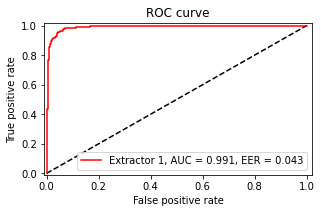

-------------------------------------------code under rogue is ran


In [8]:
if __name__ == '__main__':
    
    # Specifies what task the program runs for. 
    # 'Train'/'Classification'/'Rogue Device Detection'
    #run_for = 'Classification'
    run_for = 'Rogue Device Detection'
    
    if run_for == 'Train':

        # Train an RFF extractor.
        feature_extractor = train_feature_extractor()
        # Save the trained model.
        feature_extractor.save('Extractor.h5')
        print('-------------------------------------------code under train is ran')   
    
    elif run_for == 'Classification':
        
        # Specify the device index range for classification.
        test_dev_range = np.arange(30,40, dtype = int)
        
        # Perform the classification task.
        pred_label, true_label, acc = test_classification(file_path_enrol = 
                                                         '/workspaces/work/Dataset/dataset/Test/dataset_residential.h5',                           
                                                          #'./dataset/Test/dataset_residential.h5',
                                                          file_path_clf =
                                                          '/workspaces/work/Dataset/dataset/Test/channel problem/A.h5',
                                                          #'./dataset/Test/channel_problem/A.h5',
                                                          feature_extractor_name = 
                                                          '/workspaces/work/Dataset/model/Extractor_1.h5',
                                                         #'./models/Extractor_1.h5'
                                                          )
        
        # Plot the confusion matrix.
        conf_mat = confusion_matrix(true_label, pred_label)
        classes = test_dev_range + 1
        
        plt.figure()
        sns.heatmap(conf_mat, annot=True, 
                    fmt = 'd', cmap='Blues',
                    cbar = False,
                    xticklabels=classes, 
                    yticklabels=classes)
        plt.xlabel('Predicted label', fontsize = 20)
        plt.ylabel('True label', fontsize = 20)
        plt.savefig("/workspaces/work/image1.jpg")
        plt.show()
        print("-------------------------------------------code under classfication is ran")
        
    elif run_for == 'Rogue Device Detection':
        
        # Perform rogue device detection task using three RFF extractors.
        fpr, tpr, roc_auc, eer = test_rogue_device_detection('/workspaces/work/Dataset/model/Extractor_1.h5')
                                                           
             #('./models/Extractor_1.h5')
        
        # Plot the ROC curves.
        plt.figure(figsize=(4.8, 2.8))
        plt.xlim(-0.01, 1.02)
        plt.ylim(-0.01, 1.02)
        plt.plot([0, 1], [0, 1], 'k--')
        plt.plot(fpr, tpr, label='Extractor 1, AUC = ' + 
                 str(round(roc_auc,3)) + ', EER = ' + str(round(eer,3)), C='r')
        plt.xlabel('False positive rate')
        plt.ylabel('True positive rate')
        plt.title('ROC curve')
        plt.legend(loc=4)
        plt.savefig('roc_curve.pdf',bbox_inches='tight')
        # plt.savefig('roc_curve.pdf',bbox_inches='tight')
        plt.show()    
        print('-------------------------------------------code under rogue is ran')












In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, MaxPooling1D, Flatten, Dense
import matplotlib.pyplot as plt
cnn_model = Sequential()
cnn_model.add(Conv1D(filters=32, kernel_size=1, activation='relu', input_shape=(1, 8192)))
#cnn_model.add(MaxPooling1D())
cnn_model.add(Conv1D(64, kernel_size=1, activation='relu'))
#cnn_model.add(MaxPooling1D())
cnn_model.add(Conv1D(64, kernel_size=1, activation='relu'))
cnn_model.add(Flatten())

cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))

cnn_model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d (Conv1D)              (None, 1, 32)             262176    
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 1, 64)             2112      
_________________________________________________________________
conv1d_2 (Conv1D)            (None, 1, 64)             4160      
_________________________________________________________________
flatten (Flatten)            (None, 64)                0         
_________________________________________________________________
dense (Dense)                (None, 64)                4160      
_________________________________________________________________
dense_1 (Dense)              (None, 1)                 65        
Total params: 272,673
Trainable params: 272,673
Non-trainable params: 0
_________________________________________________________________


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
cnn_model = Sequential()
cnn_model.add(Conv2D(filters=32, kernel_size=1, activation='relu', input_shape=(1, 8192,3)))
#cnn_model.add(MaxPooling2D())
cnn_model.add(Conv2D(64, kernel_size=1, activation='relu'))
#cnn_model.add(MaxPooling2D(2))
cnn_model.add(Conv2D(64, kernel_size=1, activation='relu'))
cnn_model.add(Flatten())

In [13]:
from keras.models import Sequential
from keras.layers import  Conv1D, MaxPooling1D, Flatten, Dense

cnn_model = Sequential()
cnn_model.add(Conv1D(filters=32, kernel_size=1, activation='relu', input_shape=(1000, 8192)))
cnn_model.add(MaxPooling1D(2))
cnn_model.add(Conv1D(64, kernel_size=1, activation='relu'))
cnn_model.add(MaxPooling1D(2))
cnn_model.add(Conv1D(64, kernel_size=1, activation='relu'))
cnn_model.add(Flatten())

cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))